In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Sample - Superstore.csv',encoding = 'latin-1')

In [3]:
df.shape

(9994, 21)

In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [9]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

### Customer by sales, profit and order count

In [17]:
customer_detail = df.groupby('Customer Name').agg(sales = ('Sales','sum'),profit = ('Profit','sum'),order = ('Order ID','nunique')).reset_index()

In [13]:
customer_detail.head(10)

,Customer Name,total_sales,total_profit,order_count
0,Aaron Bergman,886.156,129.3465,3
1,Aaron Hawkins,1744.700,365.2152,7
2,Aaron Smayling,3050.692,-253.5746,7
3,Adam Bellavance,7755.620,2054.5885,8
4,Adam Hart,3250.337,281.1890,10
5,Adam Shillingsburg,3255.310,64.5374,9
6,Adrian Barton,14473.571,5444.8055,10
7,Adrian Hane,1735.514,-2.3146,7
8,Adrian Shami,58.820,21.8496,2
9,Aimee Bixby,966.710,313.6597,5


In [18]:
customer_detail.sort_values('sales',ascending = False).head(10)

,Customer Name,sales,profit,order
686,Sean Miller,25043.050,-1980.7393,5
730,Tamara Chand,19052.218,8981.3239,5
622,Raymond Buch,15117.339,6976.0959,6
757,Tom Ashbrook,14595.620,4703.7883,4
6,Adrian Barton,14473.571,5444.8055,10
441,Ken Lonsdale,14175.229,806.8550,12
671,Sanjit Chand,14142.334,5757.4119,9
334,Hunter Lopez,12873.298,5622.4292,6
672,Sanjit Engle,12209.438,2650.6769,11
156,Christopher Conant,12129.072,2177.0493,5


In [19]:
customer_detail.sort_values('order',ascending = False).head(10)

,Customer Name,sales,profit,order
259,Emily Phan,5478.0608,144.9578,17
663,Sally Hughsby,3406.8395,558.4740,13
574,Noel Staavos,2964.8230,-234.7714,13
586,Patrick Gardner,3086.9070,137.4613,13
791,Zuschuss Carroll,8025.7070,-1032.1490,13
381,Joel Eaton,6760.8150,221.7967,13
267,Erin Ashbrook,2846.7050,-52.7406,13
145,Chloris Kastensmidt,3154.8550,141.2831,13
728,Suzanne McNair,5563.3920,581.5742,12
629,Rick Bensley,4715.4660,640.5466,12


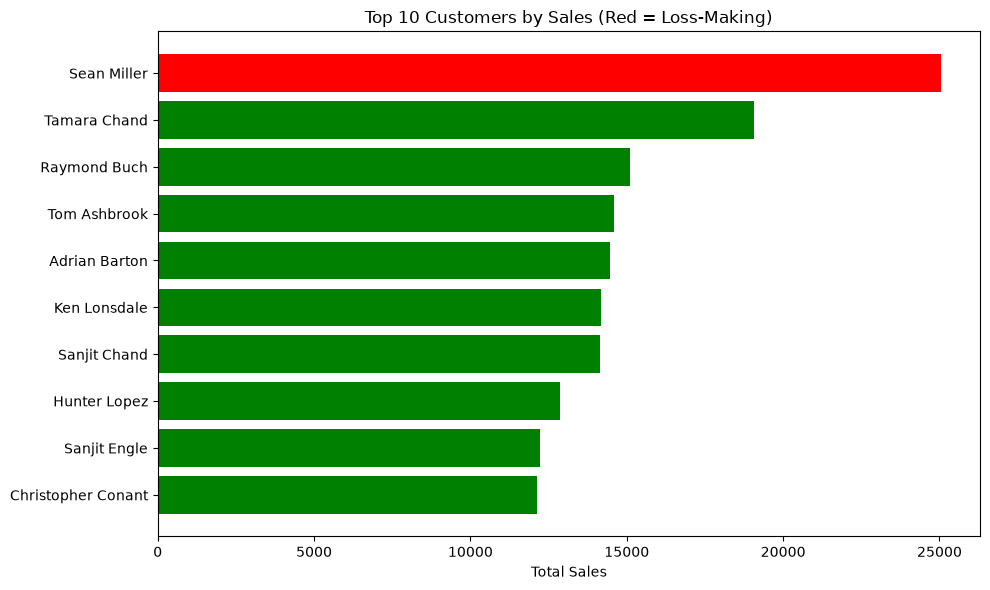

In [32]:
top10 = df.groupby('Customer Name').agg(
    sales=('Sales','sum'),
    profit=('Profit','sum')
).sort_values('sales', ascending=False).head(10)
colors = ['red' if p < 0 else 'green' for p in top10['profit']]
plt.figure(figsize=(10,6))
plt.barh(top10.index, top10['sales'], color=colors)
plt.xlabel('Total Sales')
plt.title('Top 10 Customers by Sales (Red = Loss-Making)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top10_customers_sales.png', dpi=300)
plt.show()

This chart ranks the top 10 customers by total sales, colored by profitability (green = profitable, red = loss-making). Interestingly, the #1 customer by sales, Sean Miller, is actually losing the business money due to a high average discount rate proving that sales volume alone doesn't equal customer value.

### Performance by segment

In [24]:
segment = df.groupby('Segment').agg(sales = ('Sales','sum'),profit = ('Profit','sum')).reset_index()

In [26]:
segment['profit_margin'] = segment['profit']/segment['sales']

In [28]:
segment

,Segment,sales,profit,profit_margin
0,Consumer,1.161401e+06,134119.2092,0.115481
1,Corporate,7.061464e+05,91979.1340,0.130255
2,Home Office,4.296531e+05,60298.6785,0.140343


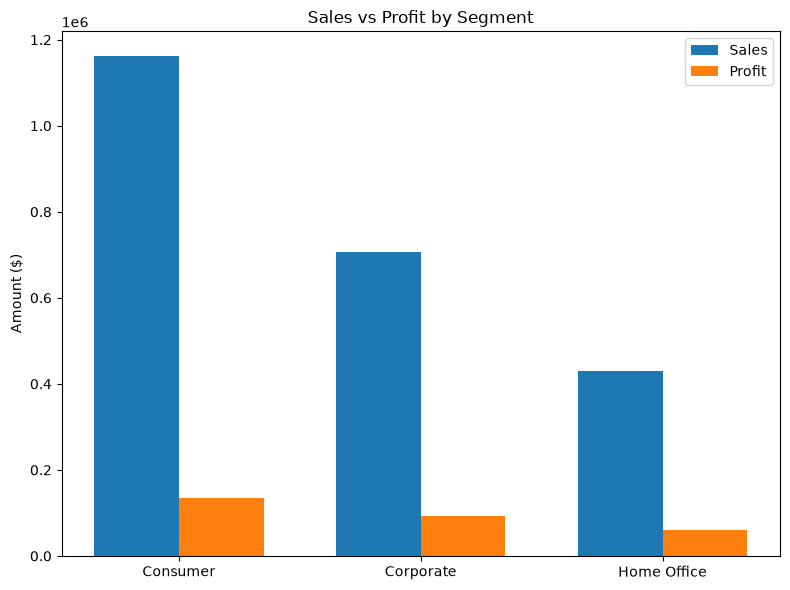

In [33]:
x = segment['Segment']
width = 0.35
positions = range(len(x))
plt.figure(figsize=(8,6))
plt.bar([p - width/2 for p in positions], segment['sales'], width, label='Sales')
plt.bar([p + width/2 for p in positions], segment['profit'], width, label='Profit')
plt.xticks(positions, x)
plt.ylabel('Amount ($)')
plt.title('Sales vs Profit by Segment')
plt.legend()
plt.tight_layout()
plt.savefig('segment_sales_vs_profit.png', dpi=300)
plt.show()

This chart compares total sales and profit across the three customer segments. Consumer generates the highest sales and profit overall, but Home Office has the best profit margin despite lower volume suggesting Consumer sales may be more discount-driven and less efficient than the other segments

### Mystery

In [31]:
df.groupby('Customer Name').agg(sales=('Sales','sum'),profit=('Profit','sum'),avg_discount=('Discount','mean')).sort_values('sales', ascending=False).head(10)

,sales,profit,avg_discount
Customer Name,,,
Sean Miller,25043.050,-1980.7393,0.246667
Tamara Chand,19052.218,8981.3239,0.116667
Raymond Buch,15117.339,6976.0959,0.094444
Tom Ashbrook,14595.620,4703.7883,0.080000
Adrian Barton,14473.571,5444.8055,0.240000
Ken Lonsdale,14175.229,806.8550,0.200000
Sanjit Chand,14142.334,5757.4119,0.063636
Hunter Lopez,12873.298,5622.4292,0.018182
Sanjit Engle,12209.438,2650.6769,0.110526


# Business Recomendation
1. Cap or tier discounts for high-volume customers.
Introduce a discount ceiling (e.g., no discretionary discount above 15%) for customers who order frequently, especially in the Consumer segment. Sean Miller-type accounts should trigger a review before another deep discount is approved.

2. Re-rank "top customers" by profit and margin, not sales.
Replace or supplement the sales leaderboard with a profit-based one for account management, loyalty rewards, and VIP treatment. This prevents rewarding customers like Sean Miller who look valuable on the surface but cost the business money.

3. Protect and invest in Corporate and Home Office relationships.
These segments have the best margins per dollar sold. Rather than pouring more discount incentives into Consumer to chase volume, shift retention effort and account management resources toward Corporate/Home Office, where profitability is structurally healthier.

# Mystery
Sean looks like the best customer but is really a discount-fueled illusion. Tamara is the quiet MVP. Big sales ≠ big value always check profit before crowning a "top customer."